# Health Insurance Fraud Detection — Exploratory Data Analysis

## Executive objective

This notebook performs a rigorous exploratory analysis of supplementary health insurance reimbursement claims before feature engineering and model training.

The analysis is designed to answer five questions:

1. **What does the claim portfolio look like?**
2. **Which observable claim, customer, provider and historical patterns are associated with fraud?**
3. **Which unusual legitimate claims could become false positives?**
4. **Which candidate features appear informative, redundant, unstable or potentially dangerous?**
5. **What modeling and operational decisions follow from the evidence?**

The prediction unit is one reimbursement claim.

The target is:

\[
Y = \texttt{is\_fraud}\in\{0,1\}
\]

with the future model expected to estimate:

\[
P(Y=1\mid X_t)
\]

using only information available at the claim scoring timestamp.

> **Important:** synthetic ground-truth metadata may be used for diagnostic analysis in this notebook, but must never enter the predictive feature matrix.

## 1. Setup and reproducibility

In [1]:
from __future__ import annotations

from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy.stats import chi2_contingency, mannwhitneyu, spearmanr
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import average_precision_score, roc_auc_score

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RANDOM_SEED = 42

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "interim"

CLAIMS_PATH = DATA_DIR / "claims.parquet"
CUSTOMERS_PATH = DATA_DIR / "customers.parquet"
PROVIDERS_PATH = DATA_DIR / "providers.parquet"
POLICIES_PATH = DATA_DIR / "policies.parquet"

FIGURES_DIR = PROJECT_ROOT / "artifacts" / "metadata" / "eda_figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")

Project root: /workspaces/Fraud-risk-model
Data directory: /workspaces/Fraud-risk-model/data/interim


In [2]:
claims = pd.read_parquet(CLAIMS_PATH)
customers = pd.read_parquet(CUSTOMERS_PATH)
providers = pd.read_parquet(PROVIDERS_PATH)
policies = pd.read_parquet(POLICIES_PATH)

tables = {
    "customers": customers,
    "providers": providers,
    "policies": policies,
    "claims": claims,
}

overview = pd.DataFrame(
    {
        "table": name,
        "rows": len(df),
        "columns": df.shape[1],
        "memory_mb": df.memory_usage(index=True, deep=True).sum() / 1024**2,
    }
    for name, df in tables.items()
)

overview

,table,rows,columns,memory_mb
0,customers,20000,6,3.7574
1,providers,1200,6,0.2816
2,policies,20000,5,3.6386
3,claims,99911,55,112.8343


In [3]:
assert claims["claim_id"].is_unique
assert claims["is_fraud"].isin([0, 1]).all()

print(f"Claims:            {len(claims):,}")
print(f"Fraud cases:       {claims['is_fraud'].sum():,}")
print(f"Fraud prevalence:  {claims['is_fraud'].mean():.3%}")
print(f"First claim:       {claims['claim_submission_timestamp'].min()}")
print(f"Last claim:        {claims['claim_submission_timestamp'].max()}")

Claims:            99,911
Fraud cases:       2,502
Fraud prevalence:  2.504%
First claim:       2023-01-01 00:22:09
Last claim:        2026-06-30 23:59:59


## 2. Feature governance and leakage guardrails

The analytical table contains variables serving different purposes.  
They must not all be treated as model inputs.

### Direct identifiers
Useful for joins, temporal aggregation, investigation tracing and debugging, but excluded from the initial model.

### Synthetic ground-truth metadata
Generated only to inspect whether the synthetic world behaves as intended. These variables would not exist at scoring time in a real insurer.

### Synthetic profile variables
Used by the simulator to generate heterogeneous populations. They are conservatively excluded from the principal predictive model because they are not directly observable operational features.

### Candidate model features
Variables potentially available at scoring time, subject to temporal-leakage verification.

In [4]:
TARGET = "is_fraud"

IDENTIFIER_COLUMNS = [
    "claim_id",
    "customer_id",
    "policy_id",
    "provider_id",
]

LEAKAGE_COLUMNS = [
    "legitimate_anomaly",
    "legitimate_anomaly_type",
    "latent_fraud_score",
    "synthetic_fraud_probability",
    "fraud_difficulty",
    "fraud_mechanism",
]

SYNTHETIC_PROFILE_COLUMNS = [
    "customer_behavior_segment",
    "provider_behavior_segment",
]

EXCLUDED_FROM_MODEL = (
    IDENTIFIER_COLUMNS
    + LEAKAGE_COLUMNS
    + SYNTHETIC_PROFILE_COLUMNS
    + [TARGET]
)

candidate_features = [
    c for c in claims.columns
    if c not in EXCLUDED_FROM_MODEL
]

assert len(candidate_features) == 42

print(f"Total columns:            {claims.shape[1]}")
print(f"Candidate model features: {len(candidate_features)}")
print(f"Excluded columns:         {len(EXCLUDED_FROM_MODEL)}")

Total columns:            55
Candidate model features: 42
Excluded columns:         13


## 3. Helper functions

The following utilities keep plots and statistics consistent throughout the notebook.

In [5]:
def save_figure(fig, name: str) -> None:
    path = FIGURES_DIR / f"{name}.png"
    fig.savefig(path, dpi=160, bbox_inches="tight")


def fraud_rate_table(
    df: pd.DataFrame,
    feature: str,
    min_count: int = 1,
) -> pd.DataFrame:
    out = (
        df.groupby(feature, dropna=False)[TARGET]
        .agg(["count", "sum", "mean"])
        .rename(columns={"sum": "fraud_count", "mean": "fraud_rate"})
        .reset_index()
    )
    out["fraud_rate_pct"] = out["fraud_rate"] * 100
    return out.loc[out["count"] >= min_count].sort_values(
        "fraud_rate",
        ascending=False,
    )


def plot_rate_by_category(
    df: pd.DataFrame,
    feature: str,
    title: str,
    min_count: int = 1,
    max_categories: int | None = None,
):
    table = fraud_rate_table(df, feature, min_count=min_count)

    if max_categories is not None:
        table = table.head(max_categories)

    table = table.sort_values("fraud_rate_pct")

    fig, ax = plt.subplots(figsize=(9, max(4.5, 0.45 * len(table))))
    ax.barh(table[feature].astype(str), table["fraud_rate_pct"])
    ax.axvline(df[TARGET].mean() * 100, linestyle="--", linewidth=1.4)
    ax.set_title(title)
    ax.set_xlabel("Fraud rate (%)")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    return fig, ax, table


def quantile_risk_table(
    df: pd.DataFrame,
    feature: str,
    q: int = 10,
) -> pd.DataFrame:
    work = df[[feature, TARGET]].dropna().copy()

    # rank first so qcut remains robust when many observations share the same value
    work["bucket"] = pd.qcut(
        work[feature].rank(method="first"),
        q=q,
        labels=False,
        duplicates="drop",
    )

    out = (
        work.groupby("bucket")
        .agg(
            count=(TARGET, "size"),
            fraud_count=(TARGET, "sum"),
            fraud_rate=(TARGET, "mean"),
            feature_min=(feature, "min"),
            feature_median=(feature, "median"),
            feature_max=(feature, "max"),
        )
        .reset_index()
    )
    out["fraud_rate_pct"] = out["fraud_rate"] * 100
    return out


def plot_quantile_risk(
    df: pd.DataFrame,
    feature: str,
    title: str,
    q: int = 10,
):
    table = quantile_risk_table(df, feature, q=q)

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(
        table["bucket"] + 1,
        table["fraud_rate_pct"],
        marker="o",
    )
    ax.axhline(
        df[TARGET].mean() * 100,
        linestyle="--",
        linewidth=1.4,
    )
    ax.set_title(title)
    ax.set_xlabel(f"{feature} quantile")
    ax.set_ylabel("Fraud rate (%)")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    return fig, ax, table


def rank_biserial_from_u(
    u_statistic: float,
    n_fraud: int,
    n_legit: int,
) -> float:
    return 2 * u_statistic / (n_fraud * n_legit) - 1


def cramers_v(table: pd.DataFrame) -> float:
    chi2 = chi2_contingency(table, correction=False)[0]
    n = table.to_numpy().sum()
    if n == 0:
        return np.nan

    r, k = table.shape
    denominator = min(k - 1, r - 1)
    if denominator <= 0:
        return np.nan

    return float(np.sqrt((chi2 / n) / denominator))


def numeric_effect_table(
    df: pd.DataFrame,
    features: list[str],
) -> pd.DataFrame:
    rows = []

    for feature in features:
        fraud = df.loc[df[TARGET] == 1, feature].dropna()
        legit = df.loc[df[TARGET] == 0, feature].dropna()

        if len(fraud) == 0 or len(legit) == 0:
            continue

        u, p = mannwhitneyu(
            fraud,
            legit,
            alternative="two-sided",
            method="asymptotic",
        )

        effect = rank_biserial_from_u(
            u,
            len(fraud),
            len(legit),
        )

        rows.append(
            {
                "feature": feature,
                "legitimate_median": legit.median(),
                "fraud_median": fraud.median(),
                "median_difference": fraud.median() - legit.median(),
                "rank_biserial_effect": effect,
                "abs_effect": abs(effect),
                "p_value": p,
            }
        )

    return (
        pd.DataFrame(rows)
        .sort_values("abs_effect", ascending=False)
        .reset_index(drop=True)
    )


def categorical_effect_table(
    df: pd.DataFrame,
    features: list[str],
) -> pd.DataFrame:
    rows = []

    for feature in features:
        contingency = pd.crosstab(
            df[feature].fillna("__MISSING__"),
            df[TARGET],
        )

        if contingency.shape[0] < 2 or contingency.shape[1] < 2:
            continue

        chi2, p, _, _ = chi2_contingency(contingency)
        cv = cramers_v(contingency)

        rows.append(
            {
                "feature": feature,
                "levels": contingency.shape[0],
                "cramers_v": cv,
                "p_value": p,
            }
        )

    return (
        pd.DataFrame(rows)
        .sort_values("cramers_v", ascending=False)
        .reset_index(drop=True)
    )

# Part I — Portfolio and data quality

## 4. Missing-data profile

Missingness is not automatically a data-quality error.  
For this project, some missing values were deliberately retained because they may occur operationally.

We examine:

- magnitude of missingness;
- whether missingness itself is associated with fraud;
- whether explicit missing indicators may later be useful.

In [6]:
missing = pd.DataFrame(
    {
        "missing_count": claims.isna().sum(),
        "missing_pct": claims.isna().mean() * 100,
    }
)

missing = (
    missing.loc[missing["missing_count"] > 0]
    .sort_values("missing_pct", ascending=False)
)

missing

,missing_count,missing_pct
days_since_same_provider_claim,98989,99.0772
days_since_policy_change,91816,91.8978
claim_to_customer_avg_ratio,30137,30.1638
customer_avg_claim_amount_365d,30137,30.1638
days_since_customer_previous_claim,19428,19.4453
has_prescription,2987,2.9897
provider_avg_claim_amount_90d,2186,2.1879
claim_to_provider_avg_ratio,2186,2.1879
provider_id,1024,1.0249
document_count,464,0.4644


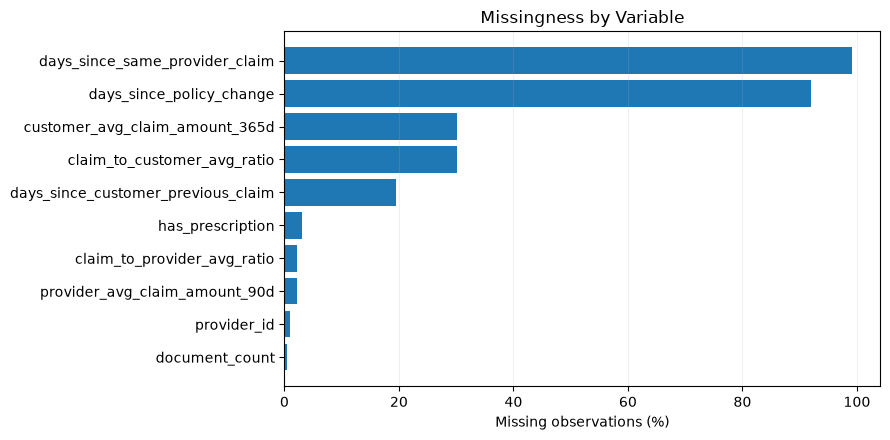

In [7]:
if not missing.empty:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    plot_data = missing.sort_values("missing_pct")
    ax.barh(plot_data.index, plot_data["missing_pct"])
    ax.set_title("Missingness by Variable")
    ax.set_xlabel("Missing observations (%)")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.2)
    plt.tight_layout()
    save_figure(fig, "01_missingness")
    plt.show()

In [8]:
missing_risk_rows = []

for feature in missing.index:
    comparison = (
        claims.assign(is_missing=claims[feature].isna())
        .groupby("is_missing")[TARGET]
        .agg(["count", "mean"])
        .reset_index()
    )
    comparison["feature"] = feature
    comparison["fraud_rate_pct"] = comparison["mean"] * 100
    missing_risk_rows.append(comparison)

missing_risk = pd.concat(missing_risk_rows, ignore_index=True)

missing_risk[
    ["feature", "is_missing", "count", "fraud_rate_pct"]
].sort_values(["feature", "is_missing"])

,feature,is_missing,count,fraud_rate_pct
4,claim_to_customer_avg_ratio,False,69774,3.0169
5,claim_to_customer_avg_ratio,True,30137,1.3173
14,claim_to_provider_avg_ratio,False,97725,2.5428
15,claim_to_provider_avg_ratio,True,2186,0.7777
6,customer_avg_claim_amount_365d,False,69774,3.0169
7,customer_avg_claim_amount_365d,True,30137,1.3173
8,days_since_customer_previous_claim,False,80483,2.8379
9,days_since_customer_previous_claim,True,19428,1.1221
2,days_since_policy_change,False,8095,2.6436
3,days_since_policy_change,True,91816,2.4919


## 5. Target imbalance and naïve baseline

In [9]:
target_summary = (
    claims[TARGET]
    .value_counts()
    .sort_index()
    .rename(index={0: "Legitimate", 1: "Fraud"})
    .to_frame("count")
)

target_summary["percentage"] = (
    target_summary["count"] / len(claims) * 100
)

target_summary

,count,percentage
is_fraud,,
Legitimate,97409,97.4958
Fraud,2502,2.5042


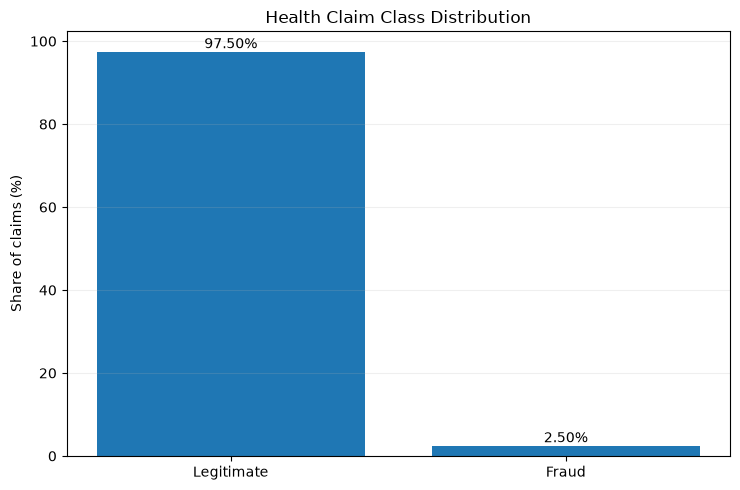

Majority-class accuracy: 97.496%
A classifier predicting every claim as legitimate would achieve 97.496% accuracy and detect 0 fraud cases.


In [10]:
fig, ax = plt.subplots(figsize=(7.5, 5))
bars = ax.bar(target_summary.index, target_summary["percentage"])

ax.set_title("Health Claim Class Distribution")
ax.set_ylabel("Share of claims (%)")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.2)

for bar, value in zip(bars, target_summary["percentage"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.2f}%",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
save_figure(fig, "02_target_distribution")
plt.show()

majority_accuracy = claims[TARGET].value_counts(normalize=True).max()

print(f"Majority-class accuracy: {majority_accuracy:.3%}")
print(
    "A classifier predicting every claim as legitimate would achieve "
    f"{majority_accuracy:.3%} accuracy and detect 0 fraud cases."
)

### Interpretation

Because fraud is rare, accuracy is not an adequate primary model-selection metric.

Later modeling will emphasize:

- **PR-AUC / Average Precision**;
- precision and recall at selected operating points;
- calibration;
- **Precision@K / Recall@K** under constrained investigation capacity;
- captured fraud amount / expected value.

## 6. Portfolio composition

In [11]:
portfolio_metrics = pd.Series(
    {
        "claims": len(claims),
        "customers_in_claims": claims["customer_id"].nunique(),
        "providers_in_claims": claims["provider_id"].nunique(dropna=True),
        "policies_in_claims": claims["policy_id"].nunique(),
        "mean_claim_amount": claims["claim_amount"].mean(),
        "median_claim_amount": claims["claim_amount"].median(),
        "fraud_rate": claims[TARGET].mean(),
    }
)

portfolio_metrics

claims                99,911.0000
customers_in_claims   19,446.0000
providers_in_claims    1,199.0000
policies_in_claims    19,446.0000
mean_claim_amount        210.8003
median_claim_amount      144.4100
fraud_rate                 0.0250
dtype: float64

# Part II — Claim and financial behavior

## 7. Claim amount distribution

Health claim amounts are typically right-skewed.  
We therefore inspect the distribution on both the original and logarithmic scale and rely on quantiles rather than means alone.

In [12]:
amount_quantiles = (
    claims["claim_amount"]
    .quantile([0, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99, 1.0])
    .rename("claim_amount")
    .to_frame()
)

amount_quantiles

,claim_amount
0.0000,8.3100
0.2500,82.5200
0.5000,144.4100
0.7500,266.4250
0.9000,440.3200
0.9500,591.3100
0.9900,"1,007.8360"
1.0000,"3,644.0700"


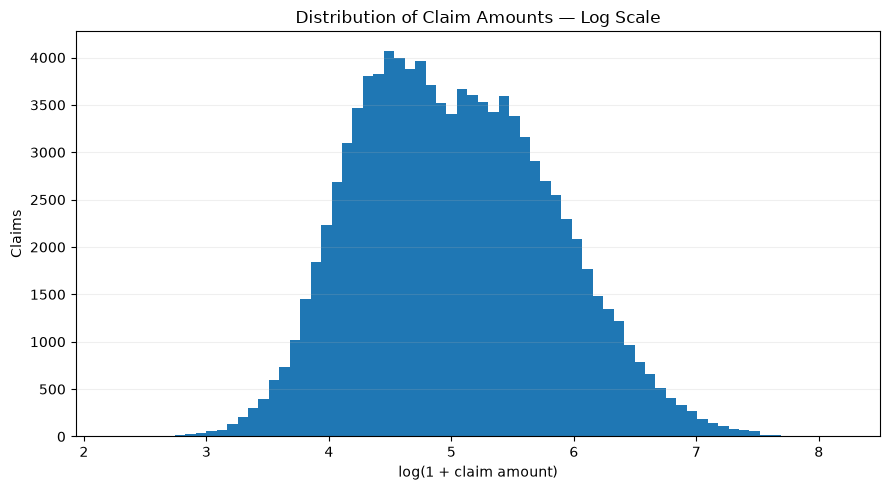

In [13]:
valid_amounts = claims.loc[claims["claim_amount"] > 0, "claim_amount"]

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(np.log1p(valid_amounts), bins=70)
ax.set_title("Distribution of Claim Amounts — Log Scale")
ax.set_xlabel("log(1 + claim amount)")
ax.set_ylabel("Claims")
ax.grid(axis="y", alpha=0.2)
plt.tight_layout()
save_figure(fig, "03_claim_amount_log_distribution")
plt.show()

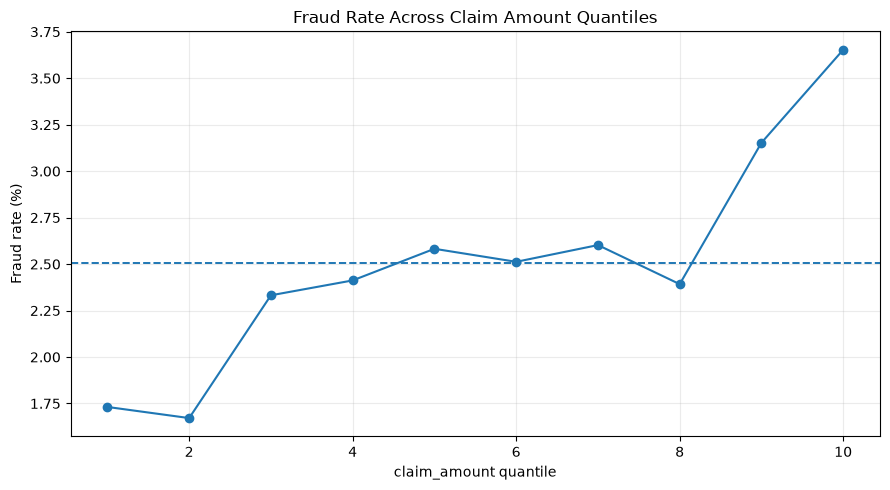

,bucket,count,fraud_count,fraud_rate,feature_min,feature_median,feature_max,fraud_rate_pct
0,0,9992,173,0.0173,8.3100,45.9150,56.4400,1.7314
1,1,9991,167,0.0167,56.4400,65.3100,73.7800,1.6715
2,2,9991,233,0.0233,73.7800,82.5200,91.8500,2.3321
3,3,9991,241,0.0241,91.8600,102.3700,114.2200,2.4122
4,4,9991,258,0.0258,114.2200,127.9700,144.4100,2.5823
5,5,9991,251,0.0251,144.4200,163.0300,183.8000,2.5123
6,6,9991,260,0.0260,183.8000,207.4400,234.4300,2.6023
7,7,9991,239,0.0239,234.4300,266.4300,307.0600,2.3922
8,8,9991,315,0.0315,307.0700,361.3900,440.3200,3.1528
9,9,9991,365,0.0365,440.4000,591.3100,"3,644.0700",3.6533


In [14]:
fig, ax, amount_risk = plot_quantile_risk(
    claims,
    feature="claim_amount",
    title="Fraud Rate Across Claim Amount Quantiles",
    q=10,
)
save_figure(fig, "04_claim_amount_quantile_risk")
plt.show()

amount_risk

## 8. Reimbursement behavior

In [15]:
financial_features = [
    "claim_amount",
    "requested_reimbursement",
    "coverage_limit",
    "reimbursement_ratio",
    "days_service_to_submission",
]

financial_summary = (
    claims.groupby(TARGET)[financial_features]
    .agg(["median", "mean"])
    .T
)

financial_summary

is_fraud                                 0        1
claim_amount               median 143.8100 169.1250
                           mean   209.6585 255.2539
requested_reimbursement    median 111.8500 129.8350
                           mean   162.2190 179.1430
coverage_limit             median 350.0000 350.0000
                           mean   477.7952 478.9768
reimbursement_ratio        median   0.8130   0.8141
                           mean     0.7920   0.7640
days_service_to_submission median   6.0000   6.0000
                           mean     7.5020   7.5092

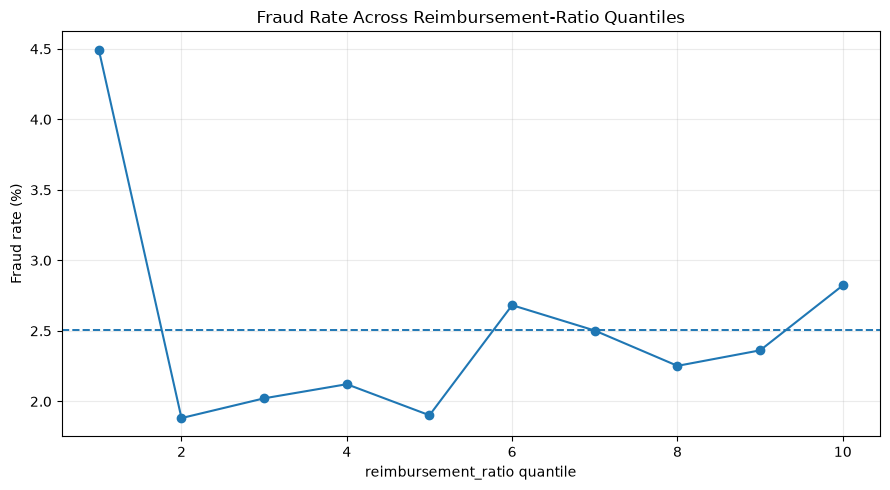

In [16]:
fig, ax, reimbursement_risk = plot_quantile_risk(
    claims,
    feature="reimbursement_ratio",
    title="Fraud Rate Across Reimbursement-Ratio Quantiles",
    q=10,
)
save_figure(fig, "05_reimbursement_ratio_risk")
plt.show()

# Part III — Categorical claim risk

## 9. Service categories: volume versus conditional fraud risk

Two distinct quantities must not be confused:

\[
P(	ext{service}\mid 	ext{fraud})
\]

and

\[
P(	ext{fraud}\mid 	ext{service})
\]

A category can account for many fraud cases simply because it represents a large share of all claims.

In [17]:
service_volume = (
    claims["service_category"]
    .value_counts()
    .rename("claim_count")
    .to_frame()
)

service_volume["portfolio_share_pct"] = (
    service_volume["claim_count"] / len(claims) * 100
)

service_risk = fraud_rate_table(
    claims,
    "service_category",
)

service_analysis = (
    service_volume
    .reset_index()
    .rename(columns={"index": "service_category"})
    .merge(
        service_risk[
            [
                "service_category",
                "fraud_count",
                "fraud_rate_pct",
            ]
        ],
        on="service_category",
        how="left",
    )
    .sort_values("fraud_rate_pct", ascending=False)
)

service_analysis

,service_category,claim_count,portfolio_share_pct,fraud_count,fraud_rate_pct
0,consultation,24115,24.1365,673,2.7908
7,other,3015,3.0177,84,2.7861
3,physiotherapy,13970,13.9824,369,2.6414
1,dental,17946,17.9620,472,2.6301
4,optical,11942,11.9526,305,2.5540
5,diagnostic,6928,6.9342,171,2.4682
6,medical_device,5986,5.9913,128,2.1383
2,pharmacy,16009,16.0233,300,1.8739


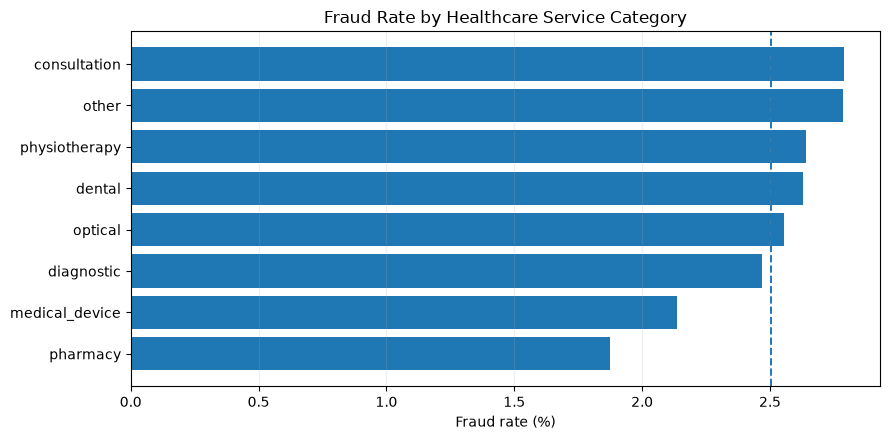

In [18]:
fig, ax, service_rate_table = plot_rate_by_category(
    claims,
    feature="service_category",
    title="Fraud Rate by Healthcare Service Category",
)
save_figure(fig, "06_service_category_fraud_rate")
plt.show()

## 10. Service codes and operational categories

In [19]:
service_code_risk = fraud_rate_table(
    claims,
    "service_code",
    min_count=200,
)

service_code_risk.head(20)

,service_code,count,fraud_count,fraud_rate,fraud_rate_pct
15,OPT_LENSES,4026,119,0.0296,2.9558
0,CONS_FOLLOWUP,8026,236,0.0294,2.9404
4,DENT_CROWN,4410,128,0.0290,2.9025
22,PHYSIO_SPECIAL,4603,132,0.0287,2.8677
16,OTHER_01,1484,42,0.0283,2.8302
2,CONS_SPEC,8062,222,0.0275,2.7537
17,OTHER_02,1531,42,0.0274,2.7433
6,DENT_SURGERY,4494,121,0.0269,2.6925
1,CONS_GP,8027,215,0.0268,2.6785
23,PHYSIO_STANDARD,4619,120,0.0260,2.5980


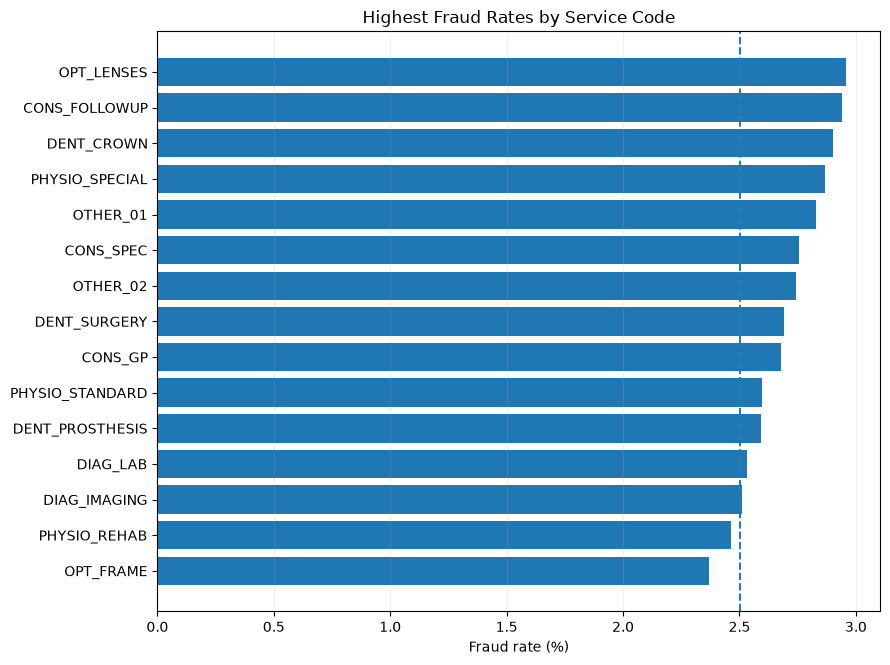

In [20]:
fig, ax, _ = plot_rate_by_category(
    claims,
    feature="service_code",
    title="Highest Fraud Rates by Service Code",
    min_count=200,
    max_categories=15,
)
save_figure(fig, "07_service_code_risk")
plt.show()

## 11. Submission and policy characteristics

In [21]:
for feature in [
    "submission_channel",
    "coverage_level",
    "provider_type",
    "provider_region",
]:
    display(fraud_rate_table(claims, feature))

,submission_channel,count,fraud_count,fraud_rate,fraud_rate_pct
2,paper,6963,186,0.0267,2.6713
1,mobile_app,35086,888,0.0253,2.5309
3,provider_direct,14742,367,0.0249,2.4895
4,web,28005,693,0.0247,2.4746
0,email,15115,368,0.0243,2.4347


,coverage_level,count,fraud_count,fraud_rate,fraud_rate_pct
1,premium,19695,501,0.0254,2.5438
2,standard,45561,1144,0.0251,2.5109
0,basic,34655,857,0.0247,2.4729


,provider_type,count,fraud_count,fraud_rate,fraud_rate_pct
1,general_practitioner,15444,452,0.0293,2.9267
2,laboratory,2268,64,0.0282,2.8219
7,physiotherapist,13970,369,0.0264,2.6414
0,dentist,17946,472,0.0263,2.6301
4,optician,11942,305,0.0255,2.5540
8,specialist,16124,407,0.0252,2.5242
5,other,222,5,0.0225,2.2523
6,pharmacy,20989,412,0.0196,1.9629
3,medical_supplier,1006,16,0.0159,1.5905


,provider_region,count,fraud_count,fraud_rate,fraud_rate_pct
2,north,21155,615,0.0291,2.9071
0,central,14554,401,0.0276,2.7553
4,west,19429,496,0.0255,2.5529
1,east,18889,456,0.0241,2.4141
3,south,25884,534,0.0206,2.0631


# Part IV — Customer behavioral risk

## 12. Customer historical activity

The purpose is not to infer that frequent healthcare use is fraudulent.  
Instead, we examine whether unusual claim frequency provides incremental contextual information.

Risk curves are preferred to simple correlation coefficients because fraud relationships may be non-linear.

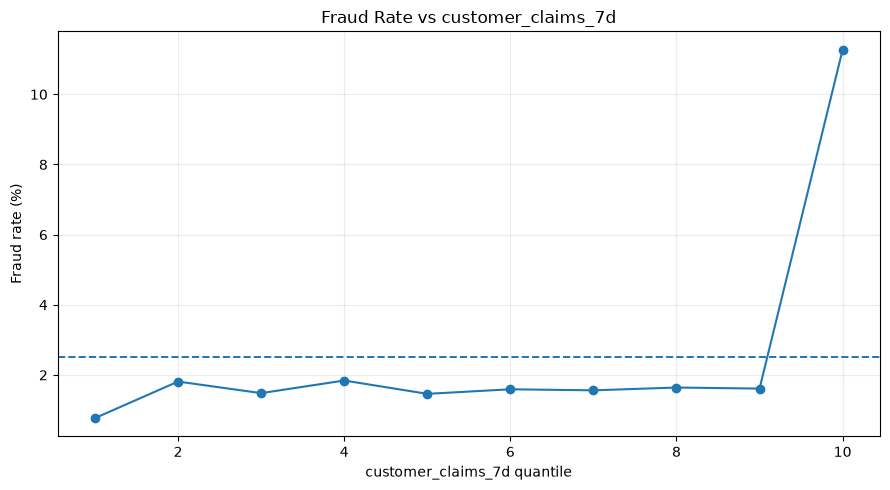

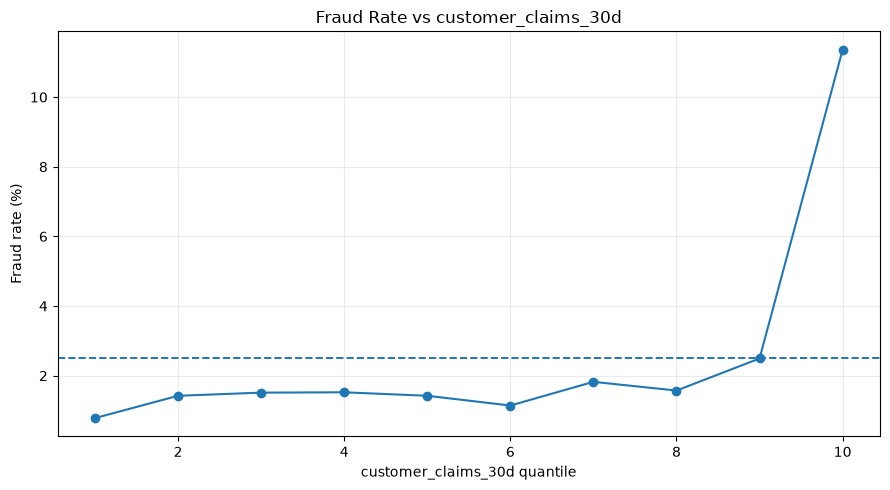

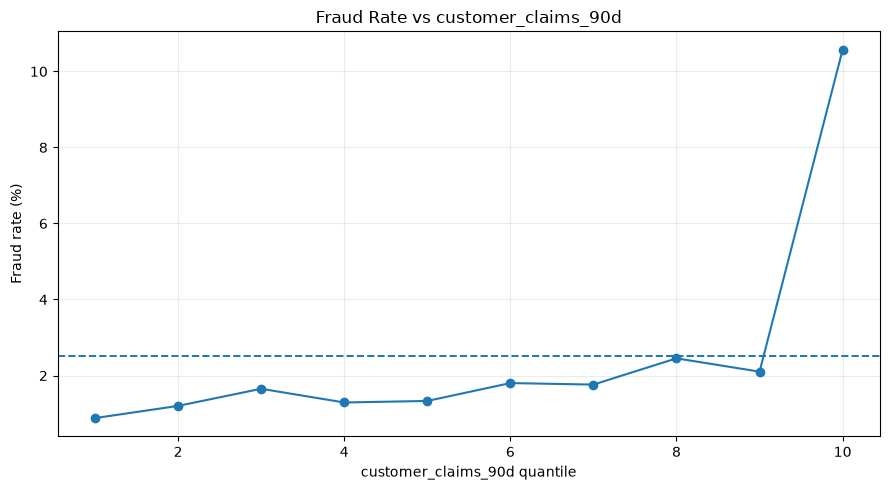

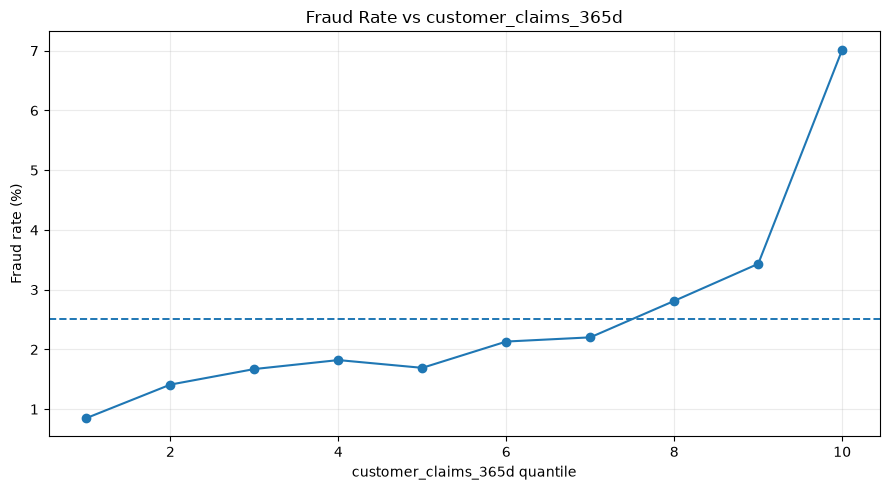

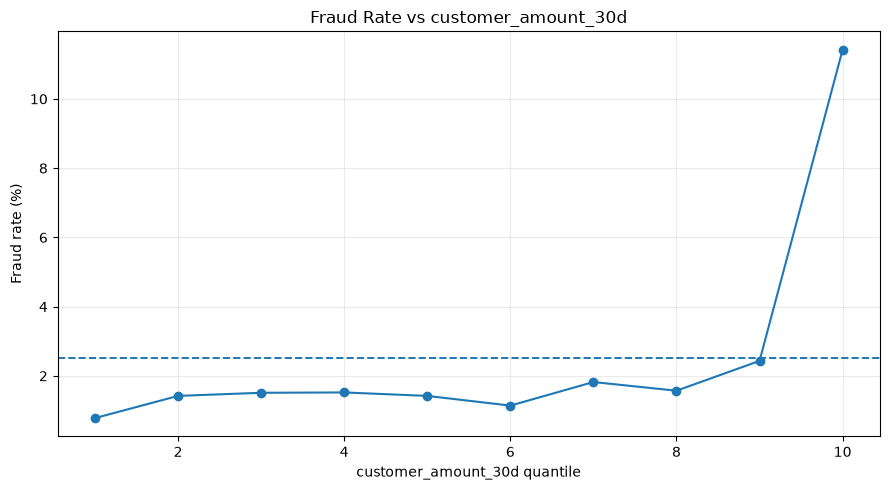

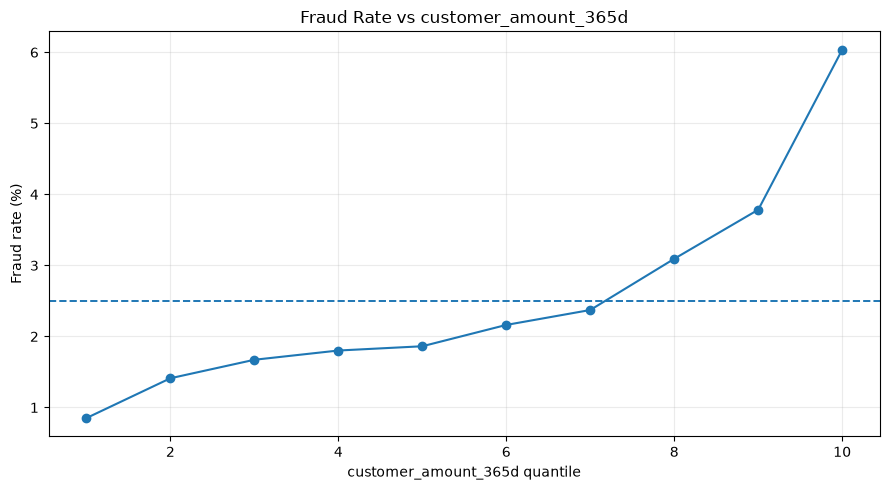

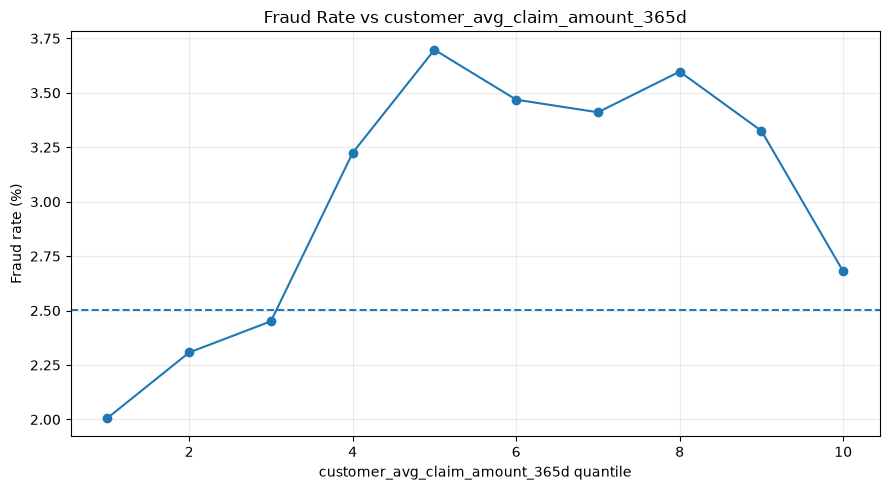

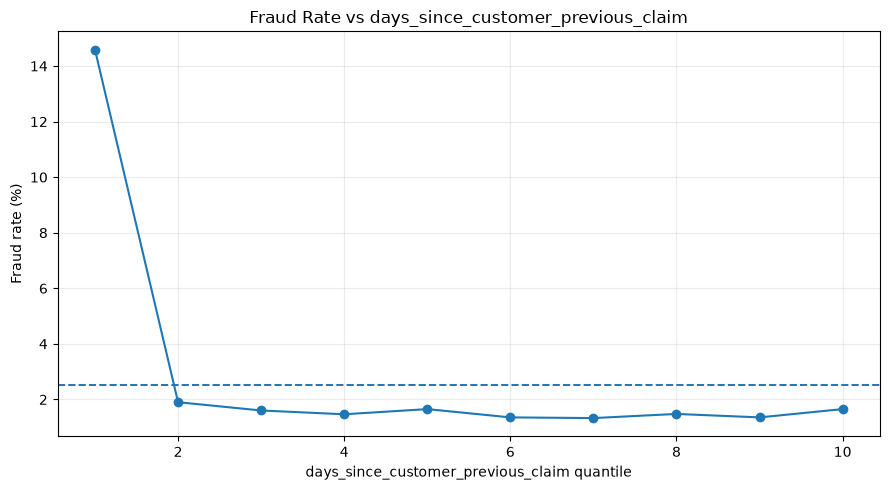

In [22]:
customer_history_features = [
    "customer_claims_7d",
    "customer_claims_30d",
    "customer_claims_90d",
    "customer_claims_365d",
    "customer_amount_30d",
    "customer_amount_365d",
    "customer_avg_claim_amount_365d",
    "days_since_customer_previous_claim",
]

for feature in customer_history_features:
    fig, ax, table = plot_quantile_risk(
        claims,
        feature=feature,
        title=f"Fraud Rate vs {feature}",
        q=10,
    )
    save_figure(fig, f"customer_{feature}")
    plt.show()

## 13. Customer tenure and age

These features require additional caution because statistical association alone is not sufficient justification for operational use.

Age in particular will later require fairness and subgroup-performance analysis.

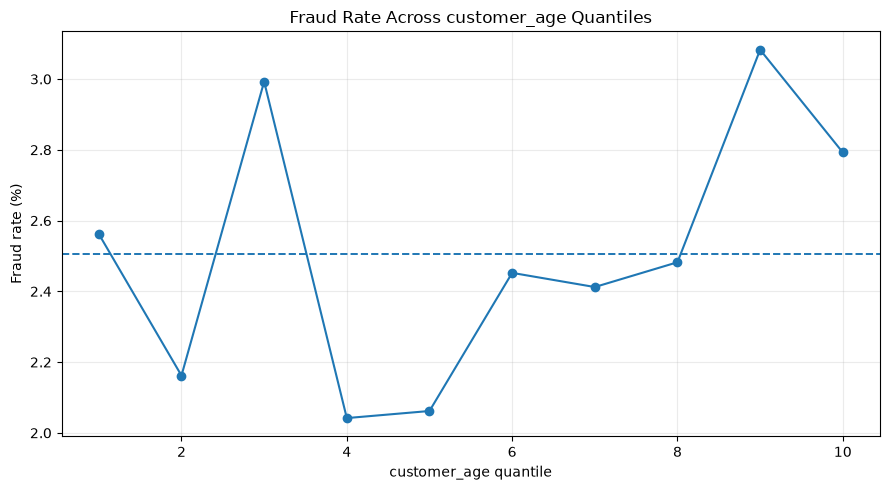

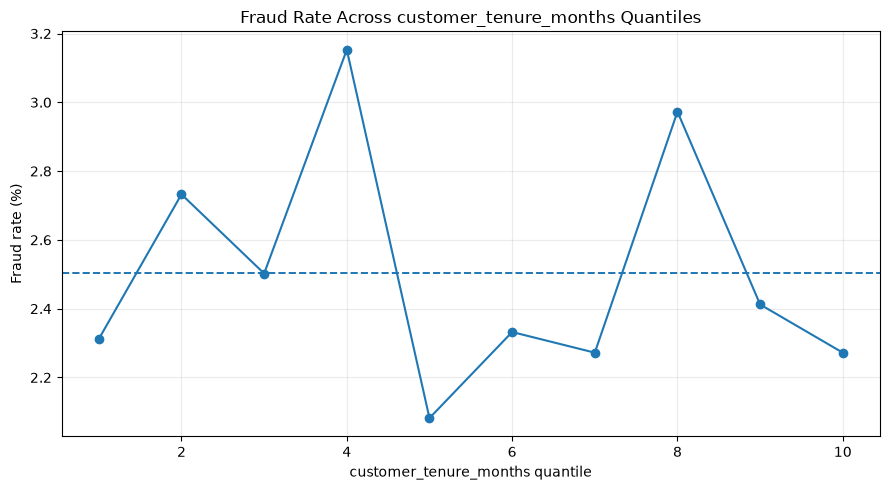

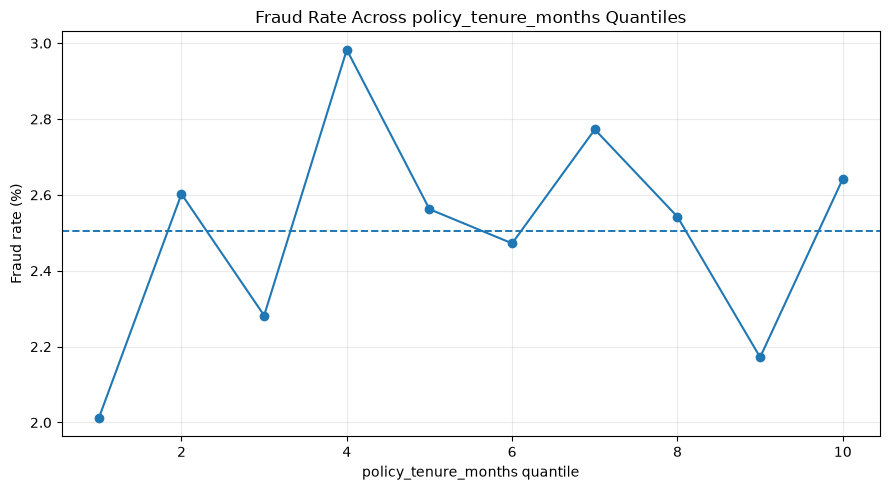

In [23]:
for feature in [
    "customer_age",
    "customer_tenure_months",
    "policy_tenure_months",
]:
    fig, ax, _ = plot_quantile_risk(
        claims,
        feature,
        title=f"Fraud Rate Across {feature} Quantiles",
        q=10,
    )
    plt.show()

# Part V — Provider behavior and relational signals

## 14. Provider historical activity

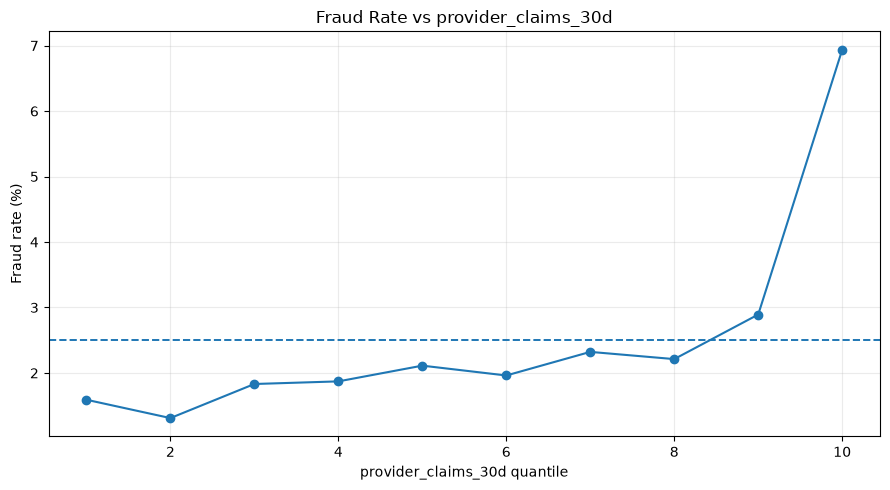

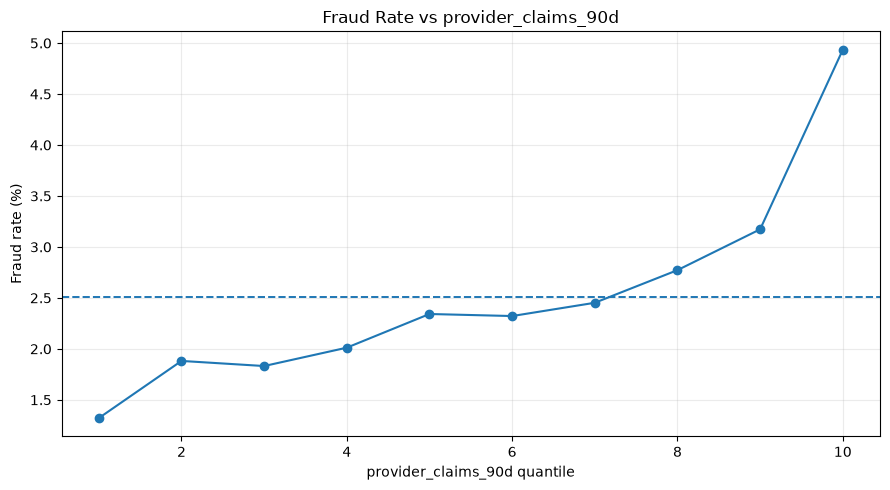

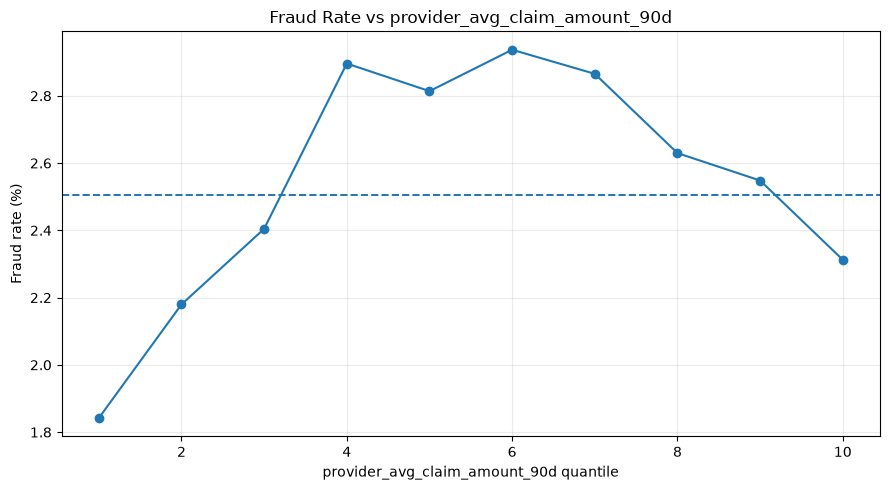

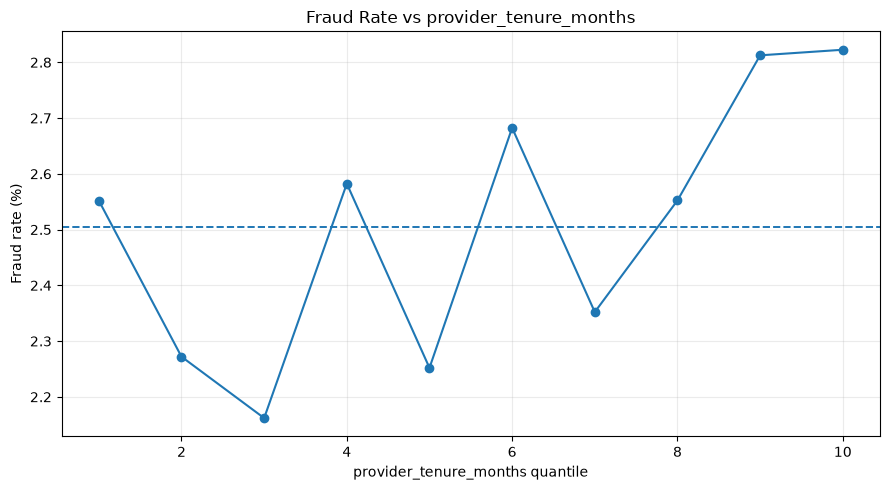

In [24]:
provider_history_features = [
    "provider_claims_30d",
    "provider_claims_90d",
    "provider_avg_claim_amount_90d",
    "provider_tenure_months",
]

for feature in provider_history_features:
    fig, ax, _ = plot_quantile_risk(
        claims,
        feature=feature,
        title=f"Fraud Rate vs {feature}",
        q=10,
    )
    save_figure(fig, f"provider_{feature}")
    plt.show()

## 15. Customer-provider interaction risk

Fraud detection often benefits from relational behavior rather than isolated claim attributes.

We analyze repeated customer-provider interactions and repeated services without using raw provider identity as a predictive input.

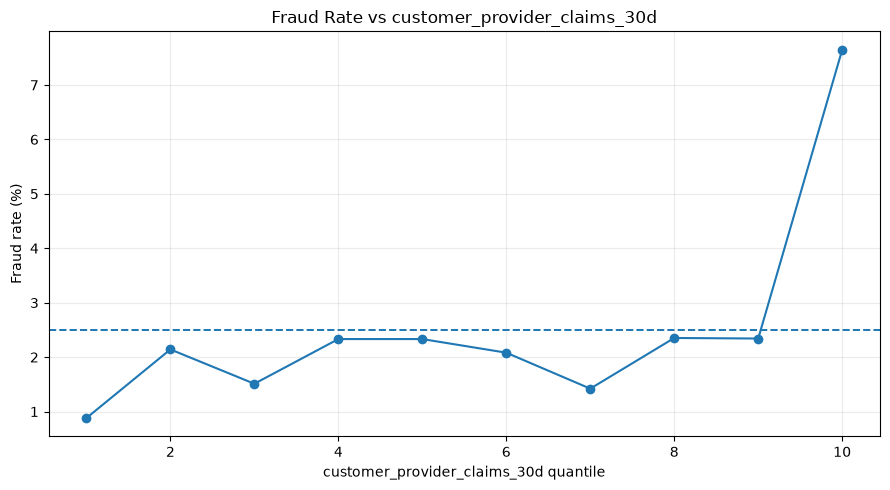

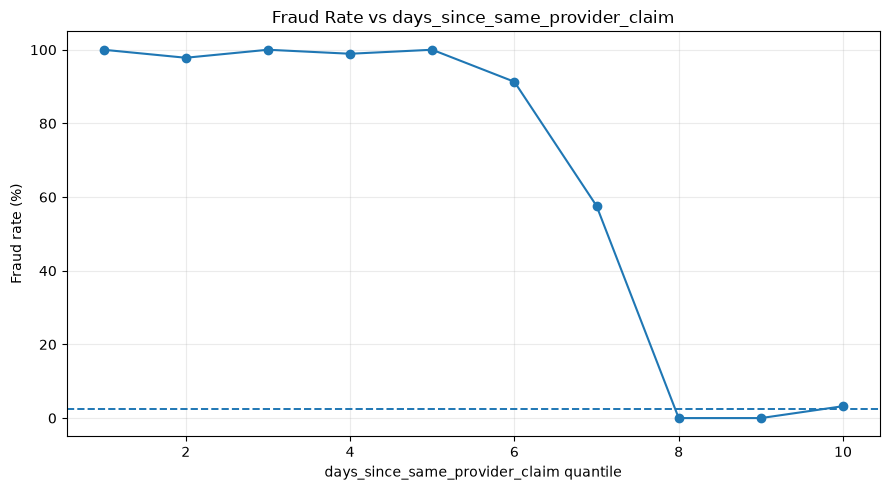

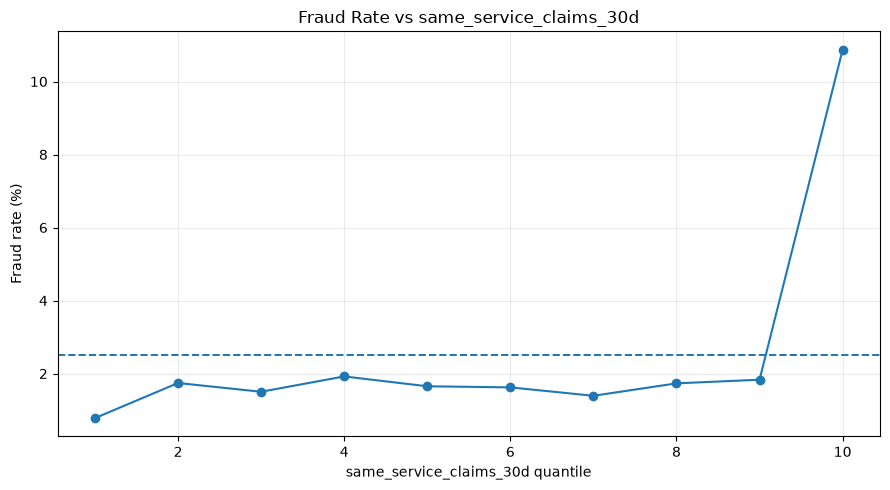

In [25]:
interaction_features = [
    "customer_provider_claims_30d",
    "days_since_same_provider_claim",
    "same_service_claims_30d",
]

for feature in interaction_features:
    fig, ax, _ = plot_quantile_risk(
        claims,
        feature=feature,
        title=f"Fraud Rate vs {feature}",
        q=10,
    )
    save_figure(fig, f"interaction_{feature}")
    plt.show()

## 16. Two-dimensional customer × provider risk surface

This view asks whether combined activity produces stronger risk than either signal alone.

In [26]:
heatmap_df = claims[
    [
        "customer_claims_30d",
        "provider_claims_30d",
        TARGET,
    ]
].dropna().copy()

heatmap_df["customer_activity_bucket"] = pd.qcut(
    heatmap_df["customer_claims_30d"].rank(method="first"),
    q=5,
    labels=["C1", "C2", "C3", "C4", "C5"],
)

heatmap_df["provider_activity_bucket"] = pd.qcut(
    heatmap_df["provider_claims_30d"].rank(method="first"),
    q=5,
    labels=["P1", "P2", "P3", "P4", "P5"],
)

risk_matrix = (
    heatmap_df.groupby(
        ["customer_activity_bucket", "provider_activity_bucket"],
        observed=True,
    )[TARGET]
    .mean()
    .unstack()
    * 100
)

risk_matrix

provider_activity_bucket,P1,P2,P3,P4,P5
customer_activity_bucket,,,,,
C1,0.7550,1.0764,0.8417,0.8236,3.0404
C2,1.1053,0.9974,1.1399,1.4345,3.2886
C3,1.0646,1.1390,1.0488,0.9881,1.9133
C4,0.7934,1.5223,1.2559,1.0420,3.1485
C5,4.1115,4.3668,5.5902,7.1429,12.8361


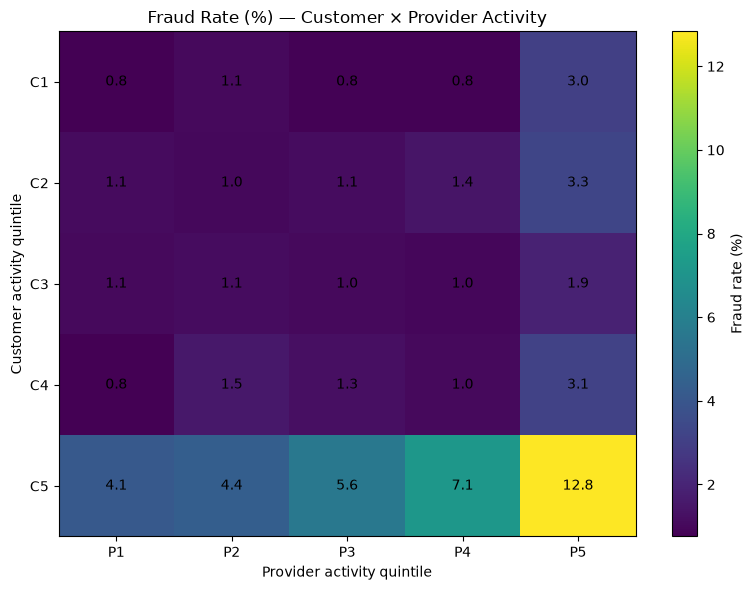

In [27]:
fig, ax = plt.subplots(figsize=(8, 6))
image = ax.imshow(risk_matrix.to_numpy(), aspect="auto")

ax.set_xticks(range(risk_matrix.shape[1]))
ax.set_xticklabels(risk_matrix.columns)
ax.set_yticks(range(risk_matrix.shape[0]))
ax.set_yticklabels(risk_matrix.index)

ax.set_xlabel("Provider activity quintile")
ax.set_ylabel("Customer activity quintile")
ax.set_title("Fraud Rate (%) — Customer × Provider Activity")

for i in range(risk_matrix.shape[0]):
    for j in range(risk_matrix.shape[1]):
        value = risk_matrix.iloc[i, j]
        ax.text(j, i, f"{value:.1f}", ha="center", va="center")

fig.colorbar(image, ax=ax, label="Fraud rate (%)")
plt.tight_layout()
save_figure(fig, "08_customer_provider_risk_matrix")
plt.show()

# Part VI — Contextual anomaly features

## 17. Claim amount relative to context

Absolute amount is often less informative than deviation from an appropriate historical reference.

We therefore study:

- current amount / historical service typical amount;
- current amount / customer historical mean;
- current amount / provider historical mean.

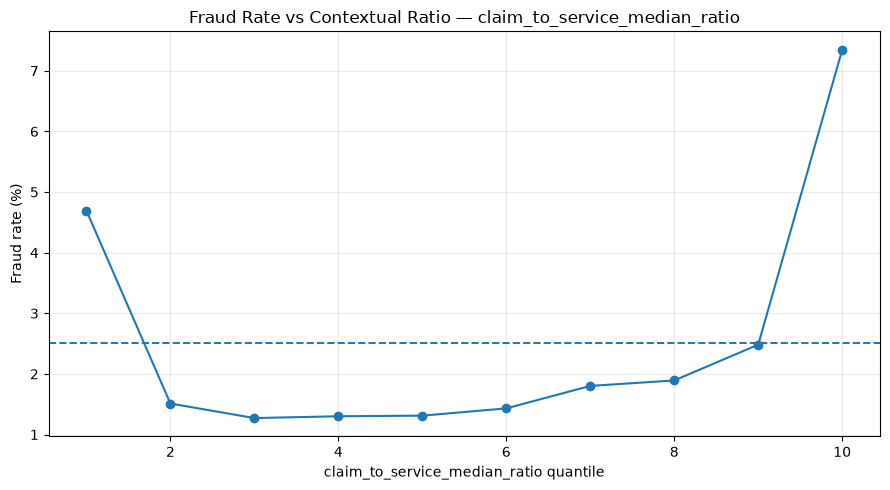

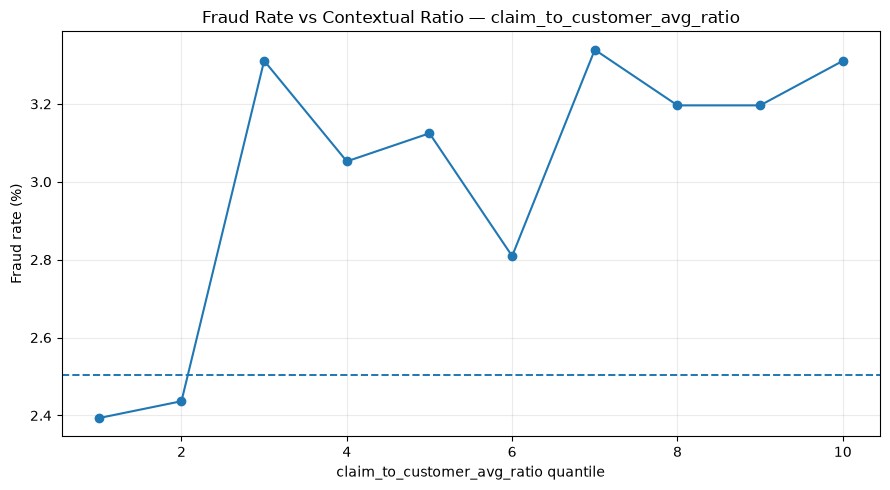

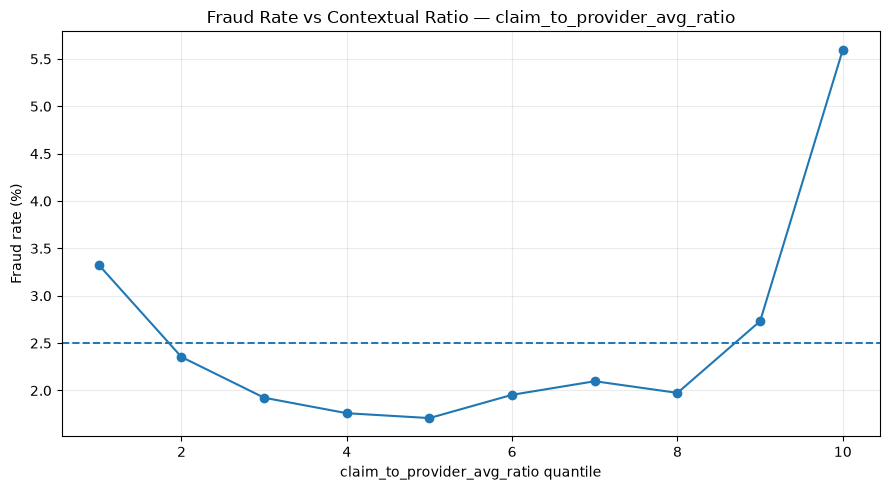

In [28]:
contextual_features = [
    "claim_to_service_median_ratio",
    "claim_to_customer_avg_ratio",
    "claim_to_provider_avg_ratio",
]

for feature in contextual_features:
    fig, ax, table = plot_quantile_risk(
        claims,
        feature=feature,
        title=f"Fraud Rate vs Contextual Ratio — {feature}",
        q=10,
    )
    save_figure(fig, f"contextual_{feature}")
    plt.show()

# Part VII — Hard negatives and synthetic diagnostic metadata

## 18. Legitimate anomalies and false-positive risk

`legitimate_anomaly` is **not a model feature**.

It identifies synthetic hard negatives: unusual but legitimate observations intentionally created to make the classification problem more realistic.

This section asks whether candidate models are likely to confuse unusual legitimate behavior with fraud.

In [29]:
diagnostic_group = np.select(
    [
        claims[TARGET].eq(1),
        claims["legitimate_anomaly"].fillna(False),
    ],
    [
        "Fraud",
        "Legitimate anomaly",
    ],
    default="Ordinary legitimate",
)

claims_diagnostic = claims.assign(
    diagnostic_group=diagnostic_group
)

claims_diagnostic["diagnostic_group"].value_counts()

diagnostic_group
Ordinary legitimate    93418
Legitimate anomaly      3991
Fraud                   2502
Name: count, dtype: int64

In [30]:
diagnostic_features = [
    "claim_to_service_median_ratio",
    "customer_claims_30d",
    "same_service_claims_30d",
    "provider_claims_30d",
    "customer_provider_claims_30d",
]

diagnostic_summary = (
    claims_diagnostic.groupby("diagnostic_group")[diagnostic_features]
    .median()
    .T
)

diagnostic_summary

diagnostic_group,Fraud,Legitimate anomaly,Ordinary legitimate
claim_to_service_median_ratio,1.2102,1.1389,0.9899
customer_claims_30d,1.0000,0.0000,0.0000
same_service_claims_30d,0.0000,0.0000,0.0000
provider_claims_30d,3.0000,2.0000,2.0000
customer_provider_claims_30d,0.0000,0.0000,0.0000


## 19. Fraud mechanisms — diagnostic only

`fraud_mechanism` is hidden synthetic ground truth and is never given to the model.

Its purpose is to check whether the synthetic dataset contains heterogeneous fraud patterns and, later, whether model recall differs materially across fraud mechanisms.

In [31]:
fraud_only = claims.loc[claims[TARGET] == 1].copy()

mechanism_summary = (
    fraud_only["fraud_mechanism"]
    .value_counts()
    .rename("count")
    .to_frame()
)

mechanism_summary["percentage"] = (
    mechanism_summary["count"] / len(fraud_only) * 100
)

mechanism_summary

,count,percentage
fraud_mechanism,,
amount_inflation,536,21.4229
frequency_abuse,462,18.4652
provider_abnormality,440,17.5859
repeated_service,381,15.2278
mixed_pattern,342,13.6691
customer_provider_pattern,341,13.6291


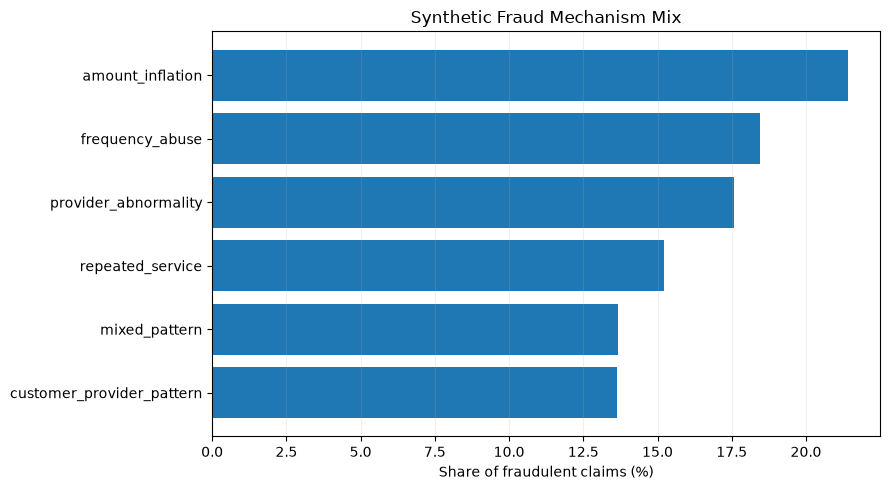

In [32]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_data = mechanism_summary.sort_values("percentage")
ax.barh(plot_data.index, plot_data["percentage"])
ax.set_title("Synthetic Fraud Mechanism Mix")
ax.set_xlabel("Share of fraudulent claims (%)")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
save_figure(fig, "09_fraud_mechanisms")
plt.show()

In [33]:
difficulty_summary = (
    fraud_only["fraud_difficulty"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percentage")
    .to_frame()
)

difficulty_summary

,percentage
fraud_difficulty,
medium,49.4404
hard,26.1391
easy,24.4205


# Part VIII — Statistical evidence and univariate signal strength

## 20. Numeric effect sizes

With nearly 100,000 observations, very small effects can have tiny p-values.

Therefore, this analysis prioritizes:

1. **effect size**;
2. direction and magnitude of median differences;
3. business plausibility;

rather than statistical significance alone.

The Mann–Whitney U test is used as a non-parametric distributional comparison.

In [34]:
numeric_candidate_features = (
    claims[candidate_features]
    .select_dtypes(include=["number"])
    .columns
    .tolist()
)

numeric_effects = numeric_effect_table(
    claims,
    numeric_candidate_features,
)

numeric_effects.head(25)

,feature,legitimate_median,fraud_median,median_difference,rank_biserial_effect,abs_effect,p_value
0,days_since_same_provider_claim,293.0606,2.3659,-290.6946,-0.9701,0.9701,0.0000
1,days_since_customer_previous_claim,118.7786,10.7345,-108.0441,-0.4625,0.4625,0.0000
2,customer_claims_30d,0.0000,1.0000,1.0000,0.4246,0.4246,0.0000
3,customer_amount_30d,0.0000,65.7750,65.7750,0.4166,0.4166,0.0000
4,customer_claims_90d,0.0000,1.0000,1.0000,0.4098,0.4098,0.0000
5,customer_claims_7d,0.0000,0.0000,0.0000,0.3823,0.3823,0.0000
6,same_service_claims_30d,0.0000,0.0000,0.0000,0.3716,0.3716,0.0000
7,customer_claims_365d,1.0000,2.0000,1.0000,0.3202,0.3202,0.0000
8,customer_amount_365d,177.7000,427.5250,249.8250,0.2953,0.2953,0.0000
9,provider_claims_30d,2.0000,3.0000,1.0000,0.2634,0.2634,0.0000


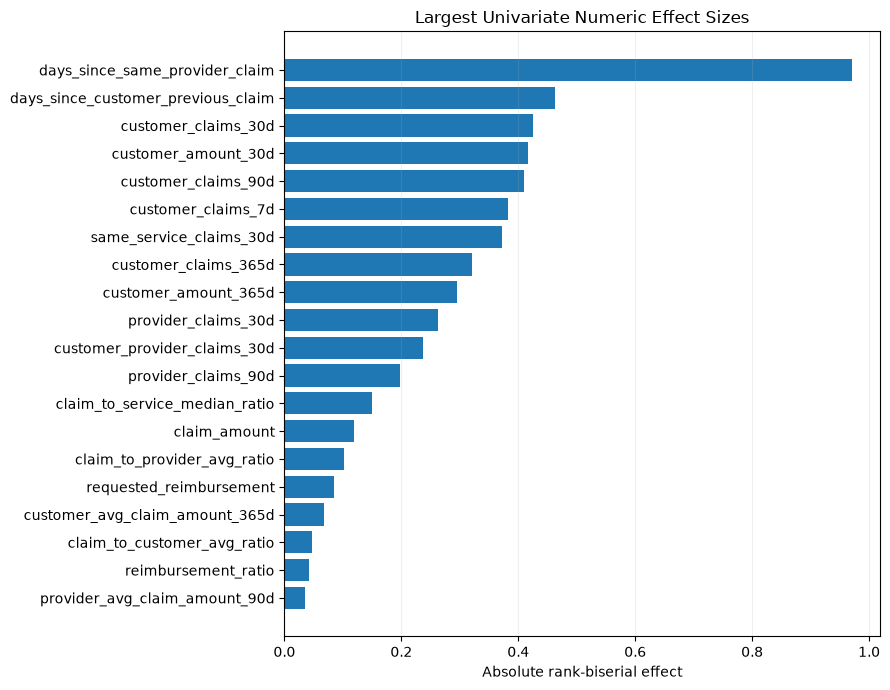

In [35]:
top_effects = numeric_effects.head(20).sort_values("abs_effect")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_effects["feature"], top_effects["abs_effect"])
ax.set_title("Largest Univariate Numeric Effect Sizes")
ax.set_xlabel("Absolute rank-biserial effect")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
save_figure(fig, "10_numeric_effect_sizes")
plt.show()

## 21. Categorical association strength

Cramér's V is used to summarize association strength between categorical variables and the binary fraud target.

In [36]:
categorical_candidate_features = (
    claims[candidate_features]
    .select_dtypes(include=["object", "bool", "category"])
    .columns
    .tolist()
)

categorical_effects = categorical_effect_table(
    claims,
    categorical_candidate_features,
)

categorical_effects

,feature,levels,cramers_v,p_value
0,service_code,24,0.0227,0.0006
1,provider_type,9,0.0208,0.0000
2,service_category,8,0.0202,0.0000
3,provider_region,5,0.0198,0.0000
4,has_prescription,3,0.0108,0.0029
5,submission_channel,5,0.0036,0.8594
6,recent_policy_change,2,0.0026,0.4237
7,coverage_level,3,0.0017,0.8722
8,has_invoice,2,0.0007,0.8640


## 22. Univariate discrimination

For numeric features, we additionally measure how well each feature ranks fraudulent versus legitimate claims on its own.

Because direction can be negative, the univariate ROC-AUC is reported as:

\[
\max(AUC, 1-AUC)
\]

This is **not** model feature importance; it is only a one-feature diagnostic.

In [37]:
univariate_rows = []

for feature in numeric_candidate_features:
    temp = claims[[feature, TARGET]].dropna()

    if temp[feature].nunique() < 2:
        continue

    auc = roc_auc_score(temp[TARGET], temp[feature])

    oriented_auc = max(auc, 1 - auc)

    univariate_rows.append(
        {
            "feature": feature,
            "raw_auc": auc,
            "oriented_auc": oriented_auc,
        }
    )

univariate_auc = (
    pd.DataFrame(univariate_rows)
    .sort_values("oriented_auc", ascending=False)
    .reset_index(drop=True)
)

univariate_auc.head(20)

,feature,raw_auc,oriented_auc
0,days_since_same_provider_claim,0.0149,0.9851
1,days_since_customer_previous_claim,0.2687,0.7313
2,customer_claims_30d,0.7123,0.7123
3,customer_amount_30d,0.7083,0.7083
4,customer_claims_90d,0.7049,0.7049
5,customer_claims_7d,0.6912,0.6912
6,same_service_claims_30d,0.6858,0.6858
7,customer_claims_365d,0.6601,0.6601
8,customer_amount_365d,0.6476,0.6476
9,provider_claims_30d,0.6317,0.6317


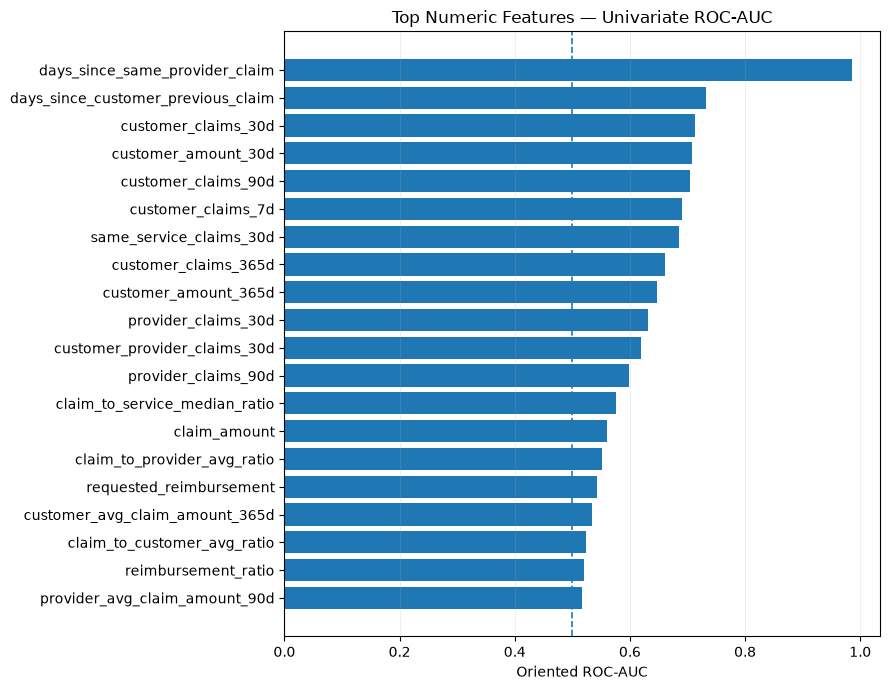

In [38]:
plot_auc = univariate_auc.head(20).sort_values("oriented_auc")

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(plot_auc["feature"], plot_auc["oriented_auc"])
ax.axvline(0.5, linestyle="--", linewidth=1.2)
ax.set_title("Top Numeric Features — Univariate ROC-AUC")
ax.set_xlabel("Oriented ROC-AUC")
ax.set_ylabel("")
ax.grid(axis="x", alpha=0.2)
plt.tight_layout()
save_figure(fig, "11_univariate_auc")
plt.show()

## 23. Mutual information — non-linear dependency diagnostic

Mutual information can capture non-linear dependence that simple correlation may miss.

It remains an exploratory ranking, not a feature-selection decision.

In [39]:
mi_features = numeric_candidate_features.copy()

mi_frame = claims[mi_features].copy()

# Median imputation is used here only for an exploratory MI diagnostic,
# not as the final model preprocessing strategy.
mi_frame = mi_frame.replace([np.inf, -np.inf], np.nan)
mi_frame = mi_frame.fillna(mi_frame.median(numeric_only=True))

mi_scores = mutual_info_classif(
    mi_frame,
    claims[TARGET],
    random_state=RANDOM_SEED,
)

mutual_information = (
    pd.DataFrame(
        {
            "feature": mi_features,
            "mutual_information": mi_scores,
        }
    )
    .sort_values("mutual_information", ascending=False)
    .reset_index(drop=True)
)

mutual_information.head(20)

,feature,mutual_information
0,days_since_same_provider_claim,0.0259
1,same_service_claims_30d,0.0225
2,customer_provider_claims_30d,0.0221
3,customer_claims_30d,0.0218
4,customer_claims_7d,0.0214
5,days_since_customer_previous_claim,0.0185
6,customer_claims_90d,0.0173
7,days_since_policy_change,0.0159
8,customer_amount_30d,0.0145
9,claim_to_service_median_ratio,0.0106


# Part IX — Redundancy and dependence structure

## 24. Correlation among candidate numeric features

We use Spearman correlation because many fraud-related features are skewed, discrete and potentially monotonic rather than linearly related.

The goal is **redundancy detection**, not causal interpretation.

In [40]:
spearman_corr = (
    claims[numeric_candidate_features]
    .corr(method="spearman")
)

# Find strongest off-diagonal relationships
corr_pairs = (
    spearman_corr
    .where(
        np.triu(
            np.ones(spearman_corr.shape),
            k=1,
        ).astype(bool)
    )
    .stack()
    .rename("spearman_corr")
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2"})
)

corr_pairs["abs_corr"] = corr_pairs["spearman_corr"].abs()

corr_pairs.sort_values("abs_corr", ascending=False).head(25)

,feature_1,feature_2,spearman_corr,abs_corr
301,customer_claims_30d,customer_amount_30d,0.9964,0.9964
29,claim_amount,requested_reimbursement,0.9763,0.9763
380,days_since_customer_previous_claim,days_since_same_provider_claim,0.9281,0.9281
331,customer_claims_365d,customer_amount_365d,0.9067,0.9067
319,customer_claims_90d,days_since_customer_previous_claim,-0.8524,0.8524
289,customer_claims_7d,days_since_same_provider_claim,-0.8098,0.8098
106,coverage_limit,service_typical_amount,0.7725,0.7725
53,claim_amount,service_typical_amount,0.7717,0.7717
357,customer_amount_365d,customer_avg_claim_amount_365d,0.7711,0.7711
80,requested_reimbursement,service_typical_amount,0.7653,0.7653


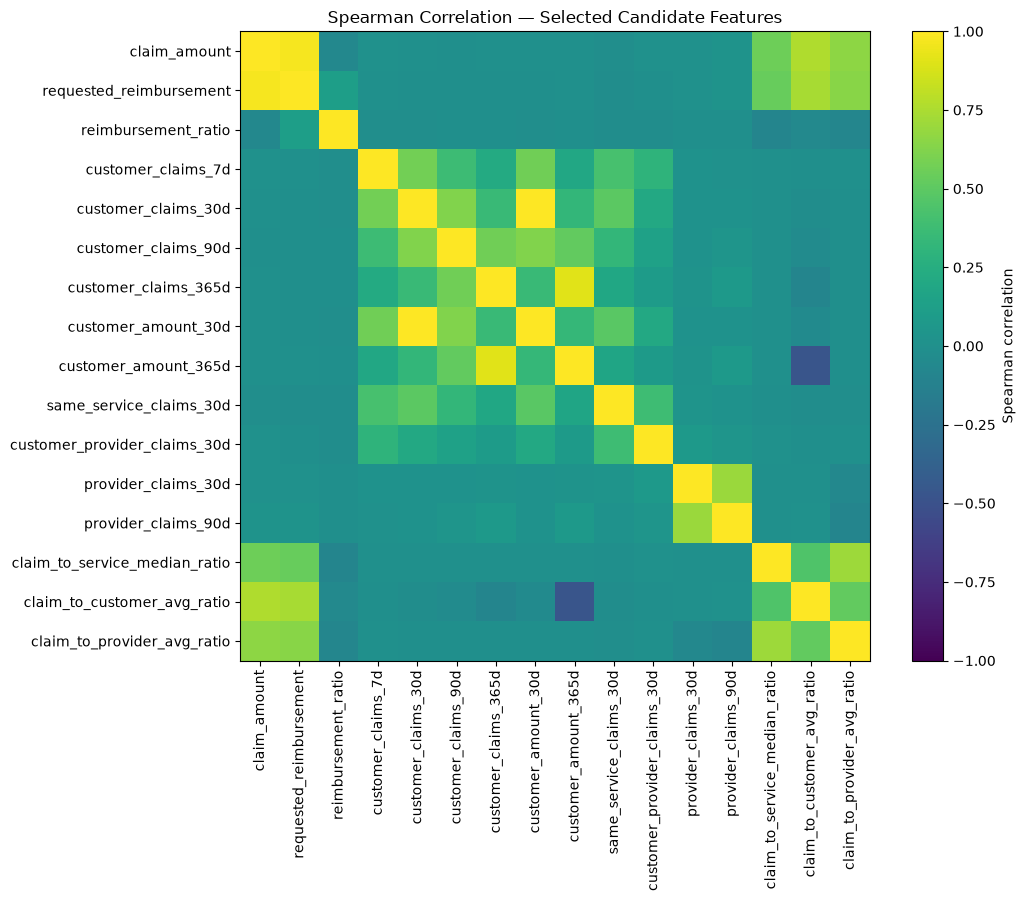

In [41]:
# Compact heatmap limited to the most informative / operational numeric features
corr_focus = [
    "claim_amount",
    "requested_reimbursement",
    "reimbursement_ratio",
    "customer_claims_7d",
    "customer_claims_30d",
    "customer_claims_90d",
    "customer_claims_365d",
    "customer_amount_30d",
    "customer_amount_365d",
    "same_service_claims_30d",
    "customer_provider_claims_30d",
    "provider_claims_30d",
    "provider_claims_90d",
    "claim_to_service_median_ratio",
    "claim_to_customer_avg_ratio",
    "claim_to_provider_avg_ratio",
]

corr_focus_matrix = claims[corr_focus].corr(method="spearman")

fig, ax = plt.subplots(figsize=(11, 9))
image = ax.imshow(corr_focus_matrix.to_numpy(), vmin=-1, vmax=1)

ax.set_xticks(range(len(corr_focus)))
ax.set_xticklabels(corr_focus, rotation=90)
ax.set_yticks(range(len(corr_focus)))
ax.set_yticklabels(corr_focus)
ax.set_title("Spearman Correlation — Selected Candidate Features")
fig.colorbar(image, ax=ax, label="Spearman correlation")

plt.tight_layout()
save_figure(fig, "12_spearman_correlation")
plt.show()

# Part X — Temporal behavior and drift

## 25. Monthly portfolio evolution

Fraud models are deployed into the future, so temporal stability is a core requirement.

We monitor monthly:

- claim volume;
- fraud prevalence;
- amount behavior;
- service mix;
- missingness.

In [42]:
monthly = (
    claims.assign(
        month=claims["claim_submission_timestamp"].dt.to_period("M").dt.to_timestamp()
    )
    .groupby("month")
    .agg(
        claims=("claim_id", "size"),
        fraud_cases=(TARGET, "sum"),
        fraud_rate=(TARGET, "mean"),
        median_claim_amount=("claim_amount", "median"),
        mean_claim_amount=("claim_amount", "mean"),
    )
    .reset_index()
)

monthly["fraud_rate_pct"] = monthly["fraud_rate"] * 100

monthly.head()

,month,claims,fraud_cases,fraud_rate,median_claim_amount,mean_claim_amount,fraud_rate_pct
0,2023-01-01,2636,0,0.0000,143.9700,211.1573,0.0000
1,2023-02-01,2277,1,0.0004,144.2900,213.6412,0.0439
2,2023-03-01,2437,40,0.0164,147.8900,217.5032,1.6414
3,2023-04-01,2223,57,0.0256,151.2000,216.6752,2.5641
4,2023-05-01,2326,59,0.0254,143.0900,212.7101,2.5365


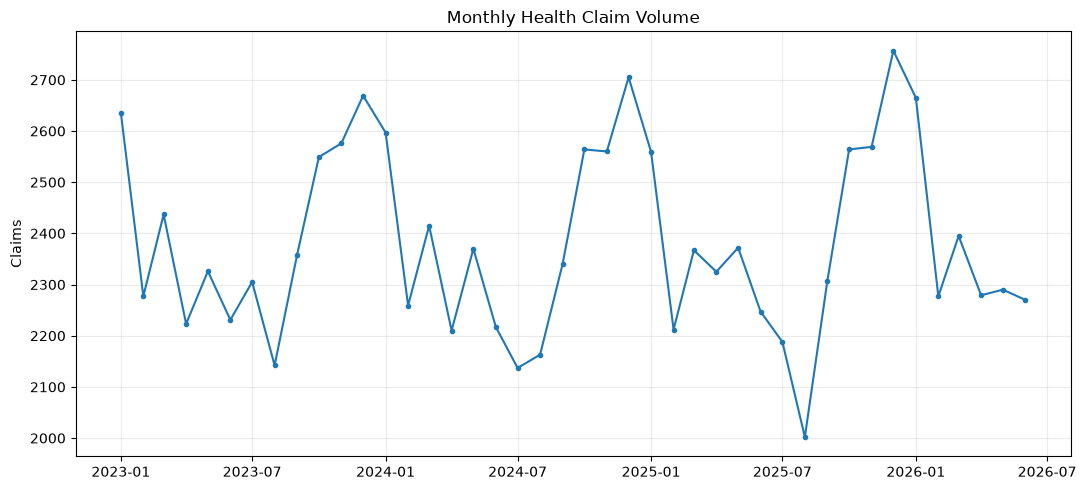

In [43]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly["month"], monthly["claims"], marker="o", markersize=3)
ax.set_title("Monthly Health Claim Volume")
ax.set_xlabel("")
ax.set_ylabel("Claims")
ax.grid(alpha=0.25)
plt.tight_layout()
save_figure(fig, "13_monthly_claim_volume")
plt.show()

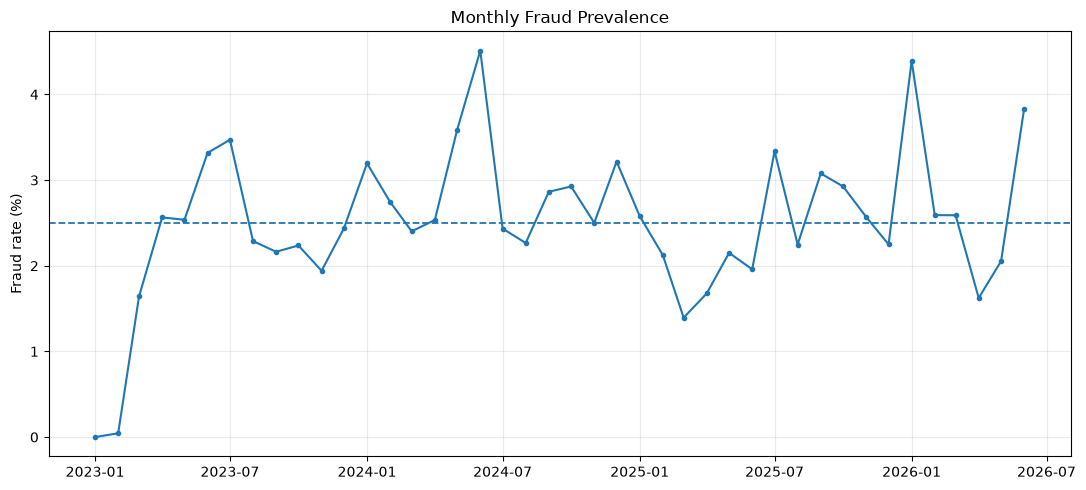

In [44]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly["month"], monthly["fraud_rate_pct"], marker="o", markersize=3)
ax.axhline(claims[TARGET].mean() * 100, linestyle="--", linewidth=1.3)
ax.set_title("Monthly Fraud Prevalence")
ax.set_xlabel("")
ax.set_ylabel("Fraud rate (%)")
ax.grid(alpha=0.25)
plt.tight_layout()
save_figure(fig, "14_monthly_fraud_rate")
plt.show()

## 26. Temporal feature stability

We compare selected feature distributions across time. Large changes can indicate data drift even when fraud prevalence remains stable.

In [45]:
stability_features = [
    "claim_amount",
    "customer_claims_30d",
    "provider_claims_30d",
    "same_service_claims_30d",
    "claim_to_service_median_ratio",
]

stability_rows = []

temp = claims.assign(
    year=claims["claim_submission_timestamp"].dt.year
)

for feature in stability_features:
    for year, group in temp.groupby("year"):
        stability_rows.append(
            {
                "feature": feature,
                "year": year,
                "count": group[feature].notna().sum(),
                "median": group[feature].median(),
                "q90": group[feature].quantile(0.90),
                "q99": group[feature].quantile(0.99),
            }
        )

stability_table = pd.DataFrame(stability_rows)
stability_table

,feature,year,count,median,q90,q99
0,claim_amount,2023,28729,145.1400,444.4820,"1,000.9864"
1,claim_amount,2024,28537,142.3600,443.1060,"1,006.2748"
2,claim_amount,2025,28469,145.5100,436.5040,"1,008.5584"
3,claim_amount,2026,14176,145.7100,434.8350,"1,011.7800"
4,customer_claims_30d,2023,28729,0.0000,1.0000,2.0000
5,customer_claims_30d,2024,28537,0.0000,1.0000,3.0000
6,customer_claims_30d,2025,28469,0.0000,1.0000,2.0000
7,customer_claims_30d,2026,14176,0.0000,1.0000,3.0000
8,provider_claims_30d,2023,28729,2.0000,5.0000,9.0000
9,provider_claims_30d,2024,28537,2.0000,5.0000,9.0000


## 27. Candidate temporal split audit

The initial project configuration proposed:

- Train: 2023-01-01 → 2025-06-30
- Validation: 2025-07-01 → 2025-12-31
- Test: 2026-01-01 → 2026-06-30

We now verify actual sample sizes and fraud prevalence before freezing those periods.

In [46]:
def assign_split(ts: pd.Series) -> pd.Series:
    return np.select(
        [
            ts <= pd.Timestamp("2025-06-30 23:59:59"),
            ts <= pd.Timestamp("2025-12-31 23:59:59"),
        ],
        [
            "train",
            "validation",
        ],
        default="test",
    )

split_audit = claims.assign(
    proposed_split=assign_split(claims["claim_submission_timestamp"])
)

split_summary = (
    split_audit.groupby("proposed_split")
    .agg(
        claims=("claim_id", "size"),
        fraud_cases=(TARGET, "sum"),
        fraud_rate=(TARGET, "mean"),
        first_claim=("claim_submission_timestamp", "min"),
        last_claim=("claim_submission_timestamp", "max"),
    )
)

split_summary["fraud_rate_pct"] = split_summary["fraud_rate"] * 100

split_summary

,claims,fraud_cases,fraud_rate,first_claim,last_claim,fraud_rate_pct
proposed_split,,,,,,
test,14176,409,0.0289,2026-01-01 00:17:34,2026-06-30 23:59:59,2.8852
train,71348,1701,0.0238,2023-01-01 00:22:09,2025-06-30 23:54:11,2.3841
validation,14387,392,0.0272,2025-07-01 00:00:15,2025-12-31 23:34:55,2.7247


# Part XI — Leakage and data-availability audit

## 28. Explicit forbidden features

In [47]:
leakage_audit = pd.DataFrame(
    {
        "feature": LEAKAGE_COLUMNS,
        "reason": [
            "Synthetic hard-negative ground truth",
            "Synthetic hard-negative subtype",
            "Hidden latent fraud-generation score",
            "Synthetic target-generation probability",
            "Synthetic target difficulty metadata",
            "Synthetic fraud mechanism ground truth",
        ],
        "allowed_in_model": False,
    }
)

leakage_audit

,feature,reason,allowed_in_model
0,legitimate_anomaly,Synthetic hard-negative ground truth,False
1,legitimate_anomaly_type,Synthetic hard-negative subtype,False
2,latent_fraud_score,Hidden latent fraud-generation score,False
3,synthetic_fraud_probability,Synthetic target-generation probability,False
4,fraud_difficulty,Synthetic target difficulty metadata,False
5,fraud_mechanism,Synthetic fraud mechanism ground truth,False


## 29. Identifier and memorization risk

Raw provider and customer IDs are kept for relational feature construction and investigation tracing, but are excluded from the first predictive model.

This reduces the risk that the model simply memorizes individual entities instead of learning transferable behavioral patterns.

In [48]:
identifier_cardinality = pd.DataFrame(
    {
        "feature": IDENTIFIER_COLUMNS,
        "unique_values": [
            claims[c].nunique(dropna=True)
            for c in IDENTIFIER_COLUMNS
        ],
        "missing_values": [
            claims[c].isna().sum()
            for c in IDENTIFIER_COLUMNS
        ],
    }
)

identifier_cardinality

,feature,unique_values,missing_values
0,claim_id,99911,0
1,customer_id,19446,0
2,policy_id,19446,0
3,provider_id,1199,1024


# Part XII — Consolidated evidence

## 30. Candidate feature evidence table

This table combines several exploratory signals:

- numeric effect size;
- univariate discrimination;
- mutual information.

No single metric determines feature inclusion.  
The purpose is to prioritize deeper feature analysis in the next notebook.

In [49]:
evidence = (
    numeric_effects[
        ["feature", "rank_biserial_effect", "abs_effect", "p_value"]
    ]
    .merge(
        univariate_auc[
            ["feature", "oriented_auc"]
        ],
        on="feature",
        how="outer",
    )
    .merge(
        mutual_information,
        on="feature",
        how="outer",
    )
)

evidence["evidence_score"] = (
    evidence["abs_effect"].fillna(0)
    + (evidence["oriented_auc"].fillna(0.5) - 0.5)
    + evidence["mutual_information"].fillna(0)
)

evidence.sort_values("evidence_score", ascending=False).head(25)

,feature,rank_biserial_effect,abs_effect,p_value,oriented_auc,mutual_information,evidence_score
18,days_since_same_provider_claim,-0.9701,0.9701,0.0000,0.9851,0.0259,1.4811
16,days_since_customer_previous_claim,-0.4625,0.4625,0.0000,0.7313,0.0185,0.7123
9,customer_claims_30d,0.4246,0.4246,0.0000,0.7123,0.0218,0.6586
6,customer_amount_30d,0.4166,0.4166,0.0000,0.7083,0.0145,0.6394
12,customer_claims_90d,0.4098,0.4098,0.0000,0.7049,0.0173,0.6320
11,customer_claims_7d,0.3823,0.3823,0.0000,0.6912,0.0214,0.5948
27,same_service_claims_30d,0.3716,0.3716,0.0000,0.6858,0.0225,0.5799
10,customer_claims_365d,0.3202,0.3202,0.0000,0.6601,0.0078,0.4882
7,customer_amount_365d,0.2953,0.2953,0.0000,0.6476,0.0037,0.4467
22,provider_claims_30d,0.2634,0.2634,0.0000,0.6317,0.0081,0.4033


# Part XIII — Executive conclusions

In [50]:
top_numeric = (
    evidence.sort_values("evidence_score", ascending=False)
    .head(12)["feature"]
    .tolist()
)

top_categorical = (
    categorical_effects.head(8)["feature"].tolist()
    if len(categorical_effects)
    else []
)

print("Top numeric exploratory signals:")
for feature in top_numeric:
    print(f"  - {feature}")

print("\nTop categorical exploratory associations:")
for feature in top_categorical:
    print(f"  - {feature}")

Top numeric exploratory signals:
  - days_since_same_provider_claim
  - days_since_customer_previous_claim
  - customer_claims_30d
  - customer_amount_30d
  - customer_claims_90d
  - customer_claims_7d
  - same_service_claims_30d
  - customer_claims_365d
  - customer_amount_365d
  - provider_claims_30d
  - customer_provider_claims_30d
  - provider_claims_90d

Top categorical exploratory associations:
  - service_code
  - provider_type
  - service_category
  - provider_region
  - has_prescription
  - submission_channel
  - recent_policy_change
  - coverage_level


## 31. Interpretation framework

Complete this section only after executing all cells and reviewing the actual outputs.

### Portfolio
- Number of claims:
- Fraud prevalence:
- Main service categories:
- Missingness requiring explicit treatment:

### Strongest observable fraud signals
- 
- 
- 

### Customer behavior
- 
- 

### Provider behavior
- 
- 

### Customer-provider interactions
- 
- 

### Contextual amount anomalies
- 
- 

### False-positive risk
- How legitimate anomalies differ from ordinary legitimate claims:
- Which candidate features could over-flag unusual legitimate behavior:

### Temporal stability
- Monthly fraud-rate stability:
- Major feature drift:
- Whether the proposed train / validation / test split remains appropriate:

### Leakage and governance
- Forbidden synthetic variables:
- Identifiers excluded from the initial model:
- Features requiring strict temporal calculation:

### Modeling implications
- Linear baseline expectations:
- Reasons a non-linear model may be necessary:
- Features that may require transformation:
- Missingness indicators worth testing:
- Highly redundant feature groups:
- Fairness-sensitive variables requiring subgroup evaluation:

### Operational implications
- Which features are understandable by an investigator:
- Which signals could support investigation prioritization:
- Which results should never be interpreted as proof of fraud:

## 32. EDA completion checklist

The EDA is complete only when the following are satisfied:

- [ ] No prohibited leakage feature has been treated as a candidate predictor.
- [ ] Missingness has been quantified and assessed against fraud.
- [ ] Class imbalance and naïve accuracy baseline have been documented.
- [ ] Financial variables have been analyzed using robust quantiles.
- [ ] Service/category volume has been separated from conditional fraud rate.
- [ ] Customer historical behavior has been explored.
- [ ] Provider historical behavior has been explored.
- [ ] Customer-provider relational signals have been explored.
- [ ] Contextual anomaly ratios have been examined.
- [ ] Legitimate hard negatives have been analyzed.
- [ ] Fraud mechanisms have been inspected diagnostically only.
- [ ] Numeric effect sizes have been reported.
- [ ] Categorical association strengths have been reported.
- [ ] Univariate discrimination and mutual information have been inspected.
- [ ] Redundant numeric feature families have been identified.
- [ ] Temporal fraud prevalence and feature stability have been assessed.
- [ ] Proposed temporal split sizes and prevalences have been verified.
- [ ] Business and modeling recommendations have been written from observed results.